In [ ]:
#there are not functions

In [1]:
import numpy as np
import pandas as pd

# 设置随机种子
np.random.seed(42)

# 生成200个样本
n_samples = 200

# 生成特征
# 1. 房屋面积 (平方米)
area = np.random.uniform(50, 200, n_samples)

# 2. 卧室数量
bedrooms = np.random.choice([1, 2, 3, 4, 5], n_samples, p=[0.1, 0.3, 0.4, 0.15, 0.05])

# 3. 房龄 (年)
age = np.random.exponential(10, n_samples)
age = np.clip(age, 0, 50)  # 限制在0-50年

# 4. 地理位置评分 (1-10分)
location = np.random.normal(6, 2, n_samples)
location = np.clip(location, 1, 10)

# 生成目标变量：房价 (万元)
# 真实关系：price = 0.8*area + 15*bedrooms - 0.5*age + 8*location + 30 + noise
noise = np.random.normal(0, 20, n_samples)
price = 0.8 * area + 15 * bedrooms - 0.5 * age + 8 * location + 30 + noise

# 创建DataFrame
data = pd.DataFrame({
    'area': area,
    'bedrooms': bedrooms,
    'age': age,
    'location': location,
    'price': price
})


In [2]:
print(data.info())
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   area      200 non-null    float64
 1   bedrooms  200 non-null    int64  
 2   age       200 non-null    float64
 3   location  200 non-null    float64
 4   price     200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB
None


,area,bedrooms,age,location,price
0,106.181018,3,1.088375,4.939485,250.383701
1,192.607146,1,23.284457,4.414254,223.941892
2,159.799091,2,7.037075,5.785939,230.886836
3,139.798773,4,17.513326,3.929515,224.035976
4,73.402796,3,3.857354,4.892701,174.896866


In [3]:
import matplotlib.pyplot as plt
%matplotlib inline

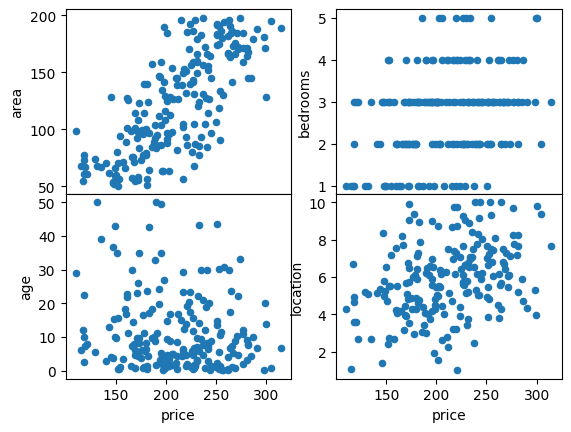

In [4]:
fig,ax=plt.subplots(2,2)
data.plot(kind='scatter',x='price',y='area',ax=ax[0,0])
data.plot(kind='scatter',x='price',y='bedrooms',ax=ax[0,1])
data.plot(kind='scatter',x='price',y='age',ax=ax[1,0])
data.plot(kind='scatter',x='price',y='location',ax=ax[1,1])
fig.subplots_adjust(hspace=0)

In [5]:
#get_ready

In [6]:
def normalize(x):
    return (x-x.mean())/x.std()

In [7]:
data_normalized=data.apply(normalize,axis=0)
data_normalized.head()

,area,bedrooms,age,location,price
0,-0.371208,0.271075,-0.903523,-0.465645,0.886275
1,1.582644,-1.665174,1.058080,-0.730107,0.298062
2,0.840946,-0.697049,-0.377800,-0.039440,0.452556
3,0.388795,1.239199,0.548050,-0.974182,0.300155
4,-1.112232,0.271075,-0.658811,-0.489201,-0.792974


In [8]:
rng=np.random.default_rng(17)
primary_parameter={'power1':rng.random((4,7)),'threshold1':rng.random(7),'power2':rng.random(7),'threshold2':rng.random(1)}

In [9]:
primary_parameter

{'power1': array([[0.84507479, 0.16097309, 0.55774455, 0.36807994, 0.21494196,
         0.38582404, 0.4281645 ],
        [0.61134311, 0.73638587, 0.01528966, 0.25404091, 0.60414585,
         0.08373669, 0.99776368],
        [0.83234612, 0.03677736, 0.56753981, 0.60934014, 0.00692658,
         0.17908387, 0.16492221],
        [0.46195791, 0.56700362, 0.45190922, 0.91977568, 0.81492421,
         0.40116605, 0.20316156]]),
 'threshold1': array([0.35832554, 0.86203504, 0.34881555, 0.99106562, 0.56576884,
        0.23684585, 0.65869731]),
 'power2': array([0.66022651, 0.51460757, 0.27909297, 0.6299182 , 0.47919082,
        0.65328881, 0.54224028]),
 'threshold2': array([0.12121114])}

In [10]:
dataTrain_fiture=data_normalized.iloc[:,:-1].values
dataTrain_truth=data_normalized.iloc[:,-1].values

In [11]:
#start train

In [12]:
data_train1=dataTrain_fiture[0]
data_train1

array([-0.37120819,  0.27107478, -0.90352266, -0.46564474])

In [13]:
level_1=data_train1@primary_parameter['power1']
level_1

array([-1.11513084, -0.15739032, -0.92610894, -1.04661153, -0.301743  ,
       -0.46912934, -0.13208166])

In [14]:
def sigmoid(x):
    return 1/(1+np.exp(-x))
    

In [15]:
level_1_to_2=sigmoid(level_1)

In [16]:
level_1_to_2[level_1_to_2<primary_parameter['threshold1']]=0    #the output of level 1

In [17]:
level_1_to_2

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.38482234, 0.        ])

In [18]:
level_2=level_1_to_2@primary_parameter['power2'].T
#level_2[level_2<primary_parameter['threshold2']]=0
if level_2<primary_parameter['threshold2']:
    level_2=0
y_hat=sigmoid(level_2)
y_hat

np.float64(0.5625210904485872)

In [19]:
y=dataTrain_truth[0]
y

np.float64(0.8862752748581326)

In [20]:
loss=1/2*(y_hat-y)**2
loss

np.float64(0.052408385961344964)

In [21]:
alph=1


In [22]:
g=y_hat*(y-y_hat)*(1-y_hat)
delta_power2=alph*g*level_1_to_2
delta_threshold2=alph*g
print(delta_power2)
print(delta_threshold2)

e=level_1_to_2*(1-level_1_to_2)*primary_parameter['power2']*g    #对后两项，我这里只是一维的输出，power2是1*7的
delta_power1=alph*data_train1.reshape(-1,1)@e.reshape(1,-1)    #e,xi都是向量，最后会做成一个4*7的
delta_threshold1=alph*e
print(delta_power1,'\n')
print(delta_threshold1)

[0.         0.         0.         0.         0.         0.03065996
 0.        ]
0.07967302766040578
[[ 0.          0.          0.          0.          0.         -0.00457399
   0.        ]
 [ 0.          0.          0.          0.          0.          0.00334015
   0.        ]
 [ 0.          0.          0.          0.          0.         -0.01113311
   0.        ]
 [ 0.          0.          0.          0.          0.         -0.00573762
   0.        ]] 

[0.         0.         0.         0.         0.         0.01232189
 0.        ]


In [23]:
primary_parameter['power2']+=delta_power2
primary_parameter['threshold2']+=delta_threshold2
primary_parameter['power1']+=delta_power1
primary_parameter['threshold1']+=delta_threshold1